In [1]:
## -- CHECK FOR 3rd PARTY LIBRARIES --
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    import skrub
except:
    %pip install -q pytorch-tabnet
    %pip install -q skrub

    from pytorch_tabnet.tab_model import TabNetClassifier
    import skrub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 10.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
# import tensorflow as tf

import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.calibration import CalibrationDisplay

import warnings

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
# tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e3/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/telco-customer-churn/'
    orig = pd.read_csv(ORIG_PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e3 | Customer Churn/_churn_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
    test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
    orig = pd.read_csv(PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
NUMS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATS   = [c for c in train.columns if c not in NUMS+[TARGET, 'id']]
BASE   = NUMS + CATS

train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
orig[TARGET]  = orig[TARGET].map({'Yes': 1, 'No': 0})

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")

Train shape: (594194, 20)
Test shape: (254655, 19)
Original shape: (7043, 20)

Total Numerical: 3
Total Categorical: 16


In [6]:
display(train.head())
train.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [7]:
train[NUMS].describe()

,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000
mean,36.577258,65.866223,2494.377057
std,25.061922,31.067444,2353.916710
min,1.000000,18.250000,18.800000
25%,12.000000,29.900000,639.650000
50%,35.000000,74.100000,1433.650000
75%,62.000000,90.800000,4263.800000
max,72.000000,118.750000,8684.800000


In [8]:
## -- FIX ORIGINAL COLUMN --
orig['TotalCharges'] = orig['TotalCharges'].replace(' ', np.nan).astype(float)
orig['TotalCharges'] = orig['TotalCharges'].fillna(orig['TotalCharges'].median())

display(orig.head())
orig.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


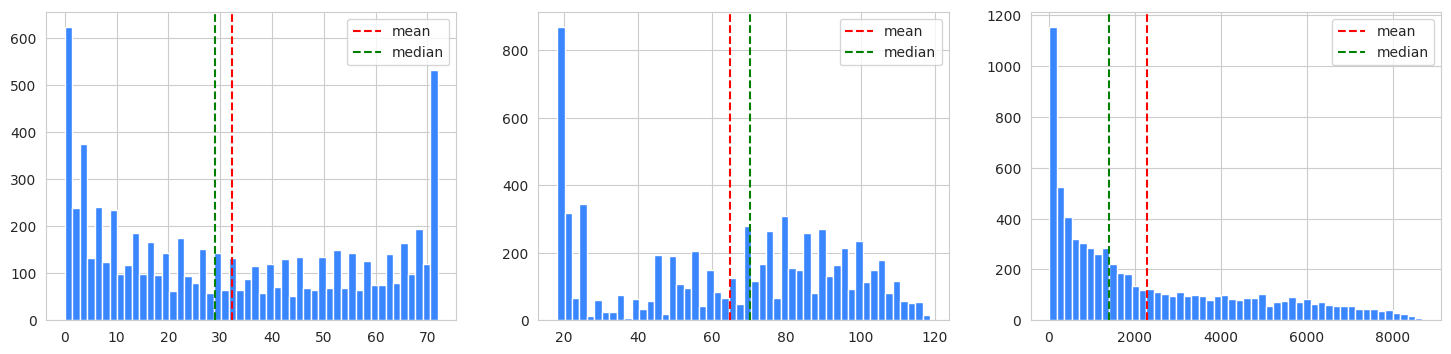

In [9]:
plt.figure(figsize=(18, 4))
for i, col in enumerate(NUMS):
    plt.subplot(1, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.legend()

plt.show()

In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
Train,72,1921,31910,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Original,73,1585,6531,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Test,72,1875,24995,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4


## FEATURE ENGINEERING

In [11]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [12]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [13]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 19


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,0


# ML TRAINING

In [14]:
def Trainer_CV(
    model_name, params, train_df, test_df, features, target, kf,
    metrics=['log_loss'], cats=None, dim_cols=None, show_df=False,
    ):

    print(f"\n==================== Starting Cross-Validation for {model_name} ====================")
    start = time()

    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], train_df[target])):
        print(f"\n ***** FOLD {idx + 1}/{kf.n_splits} | ", end='')

        # Split data for the current fold
        X_train, X_val = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
        y_train, y_val = train_df.loc[train_idx, target], train_df.loc[val_idx, target]

        X_test = test_df[features].copy()

        ## ===============================================================================

        ## -- Define categorical features for categorical embeddings
        combined = pd.concat([X_train, X_val, X_test])
        for col in dim_cols:
            l_enc = LabelEncoder()
            l_enc.fit(combined[col].astype(str))

            X_train[col] = l_enc.transform(X_train[col].astype(str))
            X_val[col]   = l_enc.transform(X_val[col].astype(str))
            X_test[col]  = l_enc.transform(X_test[col].astype(str))

        new_features = X_train.columns.tolist()

        categorical_dims = { col: X_train[col].nunique() for col in dim_cols }
        
        cat_cols_in_features = [ f for f in dim_cols if f in new_features ]
        cat_idxs = [ new_features.index(f) for f in dim_cols ]
        cat_dims = [ categorical_dims[f] for f in new_features if f in dim_cols ]

        print(f"X_train shape: {X_train.shape} *****")
        print()
        print('cat_idxs:', cat_idxs)
        print('cat_dims:', cat_dims)
        ## ===============================================================================

        if show_df:
            display(X_train.head(3))

        model = TabNetClassifier(**params, cat_idxs=cat_idxs, cat_dims=cat_dims)

        model.fit(
            X_train.to_numpy(), y_train.to_numpy(),
            eval_set=[(X_val.to_numpy(), y_val.to_numpy())],
            eval_metric=metrics,
            # max_epochs=30, patience=5,
            # batch_size=2048,
            # virtual_batch_size=512,
             drop_last=False,
        )

        ## -- Predict on validation and test sets --
        oof_preds[val_idx] = model.predict_proba(X_val.to_numpy())[:, 1].ravel()
        test_preds += model.predict_proba(X_test.to_numpy())[:, 1].ravel()

        ## -- Calculate and print fold score --
        fold_auc = roc_auc_score(y_val.to_numpy(), oof_preds[val_idx])
        fold_scores.append(fold_auc)
        print(f"{YELLOW} • FOLD {idx + 1} AUC: {fold_auc:.5f} {RESET}")

        ## -- Clean up memory --
        del X_train, y_train, y_val, X_test
        gc.collect()
        torch.cuda.empty_cache()

    ## -- Average the test predictions --
    test_preds /= kf.n_splits

    ## -- Print final cross-validation results --
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f" • FOLD {i+1} AUC: {score:.5f}")

    ## -- Calculate final out-of-fold AUC --
    oof_auc = np.round(roc_auc_score(train_df[target], oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_auc}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} \u00b1 {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_auc,
        'model': model,
        'val_data': X_val,
        'columns': X_val.columns,
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [15]:
all_model_predictions = {}

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

N_SPLITS = 10
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

kf

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

In [16]:
x_sample, x_sample2 = train_test_split(train, train_size=0.2, stratify=train[TARGET], random_state=0)
x_sample.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
235601,Female,0,Yes,Yes,25,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),74.75,1867.70,0
3864,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.90,70.90,1
86204,Male,0,Yes,No,45,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,Yes,Credit card (automatic),99.30,4698.05,0


In [17]:
version_name = 'tabnetV0_'

USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

if all_model_predictions:
    all_model_predictions.clear()

params = {
    # 'n_d': 8,
    # 'n_a': 8,
    # 'n_steps': 3,
    # 'gamma': 1.3,
    # 'n_independent': 2,
    # 'n_shared': 2,
    # 'epsilon': 1e-15,
    # 'lambda_sparse': 1e-3,
    # 'optimizer_fn': optim.Adam,
    # 'cat_emb_dim': 1,
    # 'optimizer_params': {'lr': 0.04},#, 'weight_decay': 0.01
    # 'scheduler_fn': torch.optim.lr_scheduler.ReduceLROnPlateau,
    # 'scheduler_params': dict(mode='min', factor=0.5, patience=5),
    # 'mask_type': 'sparsemax',
    'verbose': 1,
    'seed': SEED,
}

for metric in ['logloss', 'auc']:
    n = version_name + str(metric)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=params,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        metrics=[metric],
        dim_cols=CATS,
    )


==================== Starting Cross-Validation for tabnetV0_logloss ====================

 ***** FOLD 1/10 | X_train shape: (534774, 19) *****

cat_idxs: [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
cat_dims: [2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 4]
epoch 0  | loss: 0.33281 | val_0_logloss: 0.31316 |  0:00:28s
epoch 1  | loss: 0.31255 | val_0_logloss: 0.30794 |  0:00:57s
epoch 2  | loss: 0.31021 | val_0_logloss: 0.30631 |  0:01:26s
epoch 3  | loss: 0.30831 | val_0_logloss: 0.30623 |  0:01:54s
epoch 4  | loss: 0.30764 | val_0_logloss: 0.30565 |  0:02:23s
epoch 5  | loss: 0.30716 | val_0_logloss: 0.30848 |  0:02:50s
epoch 6  | loss: 0.30682 | val_0_logloss: 0.30584 |  0:03:18s
epoch 7  | loss: 0.30668 | val_0_logloss: 0.30618 |  0:03:46s
epoch 8  | loss: 0.30739 | val_0_logloss: 0.30712 |  0:04:14s
epoch 9  | loss: 0.30721 | val_0_logloss: 0.30767 |  0:04:42s
epoch 10 | loss: 0.30669 | val_0_logloss: 0.30896 |  0:05:10s
epoch 11 | loss: 0.30676 | val_0_logloss: 0.3051

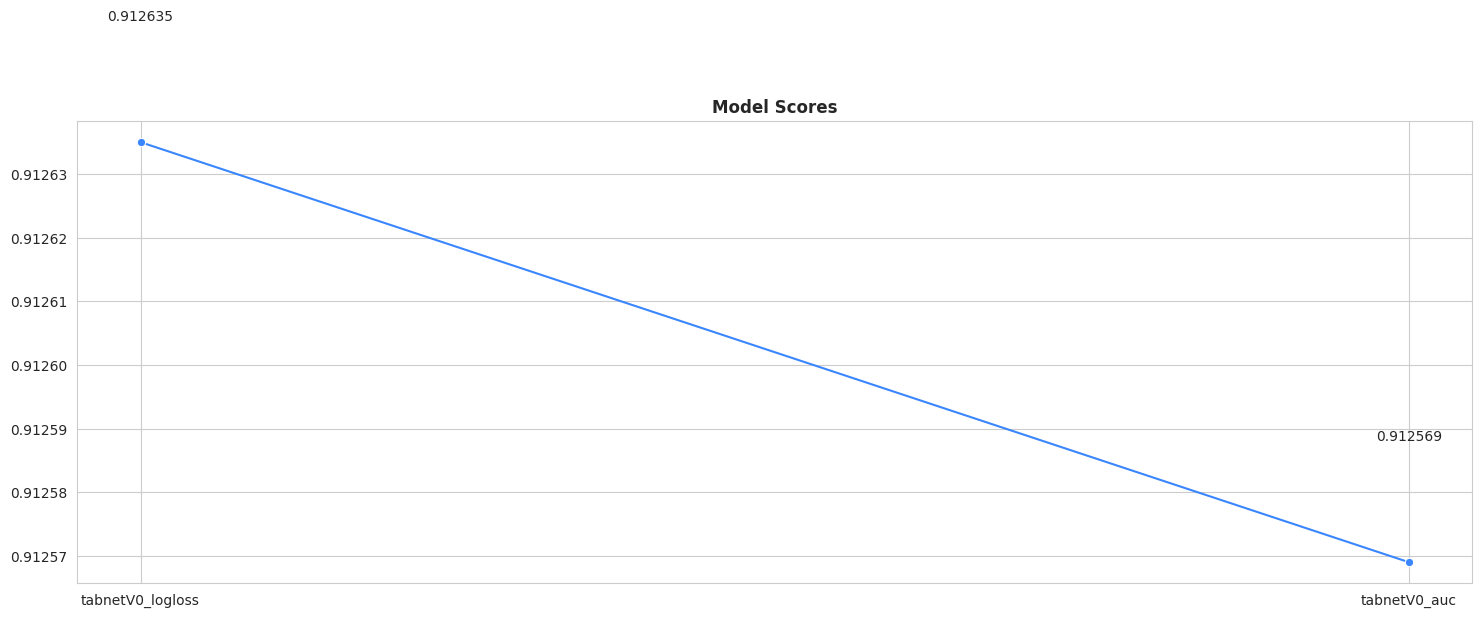

In [18]:
## -- Get models scores --
all_model_scores = {}

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

plt.figure(figsize=(18, 6))
sns.lineplot(all_model_scores, marker='o')
# pd.Series(all_model_scores).plot(marker='o')
plt.title('Model Scores', fontweight='semibold')
plt.tick_params('x', rotation=0)

for i, score in enumerate(all_model_scores.values()):
    plt.text(float(i), score+2e-5, score, ha='center', va='center_baseline')

plt.show()

In [19]:
## -- Get oof predictions --
all_model_oof = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_oof = pd.concat([all_model_oof, pd.DataFrame({n: y})], axis=1)

all_model_oof.to_parquet(f"oof_{version_name}_models.parquet", index=False)
all_model_oof.head()

,tabnetV0_logloss_912635,tabnetV0_auc_912569
0,0.012066,0.008438
1,0.001278,0.001278
2,0.319097,0.319097
3,0.817840,0.817840
4,0.862230,0.776088


In [20]:
## -- Get test predictions --
all_model_test = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_test = pd.concat([all_model_test, pd.DataFrame({n: y})], axis=1)

all_model_test.to_parquet(f"test_{version_name}_models.parquet", index=False)
all_model_test.head()

,tabnetV0_logloss_912635,tabnetV0_auc_912569
0,0.068333,0.065679
1,0.002352,0.001909
2,0.112695,0.117079
3,0.003418,0.003232
4,0.459851,0.472870


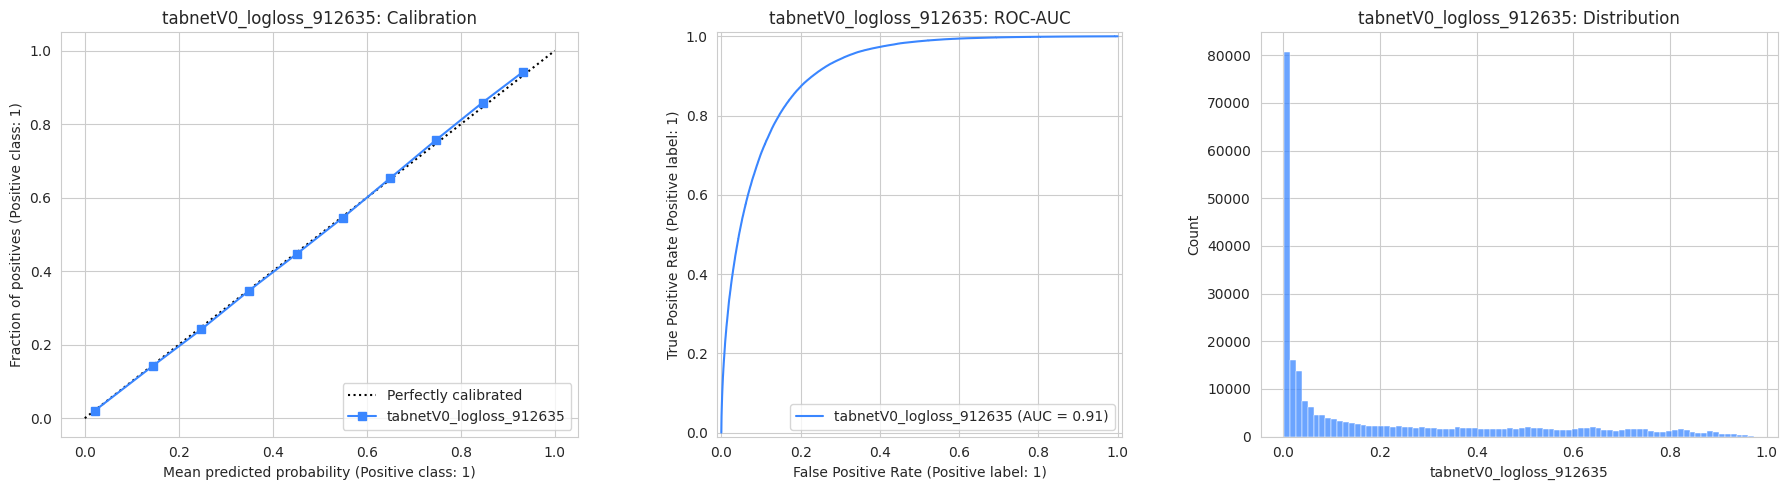

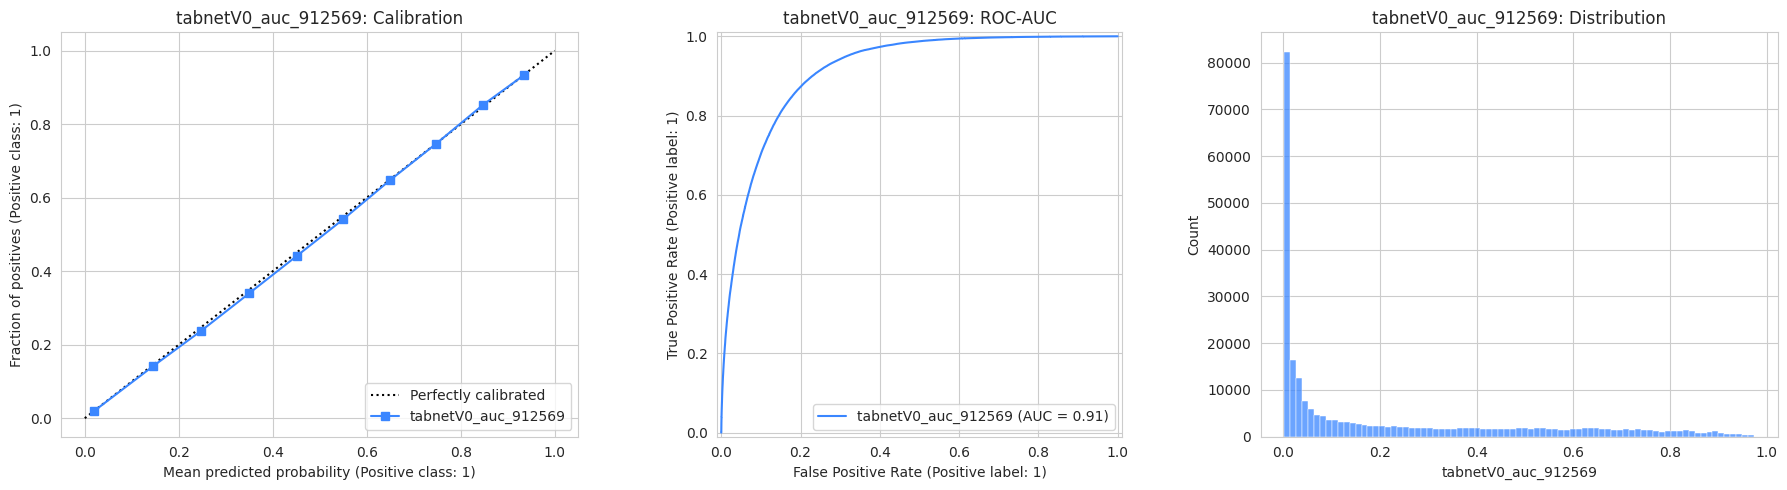

In [21]:
## -- PLOT PREDICTIONS --
for i, n in enumerate(all_model_test.columns):
    _, axs = plt.subplots(1, 3, figsize=(18, 5))

    CalibrationDisplay.from_predictions(train_data[TARGET], all_model_oof[n], n_bins=10, name=n, ax=axs[0])
    axs[0].set_title(f"{n}: Calibration")

    RocCurveDisplay.from_predictions(train_data[TARGET], all_model_oof[n], name=n, ax=axs[1])
    axs[1].set_title(f"{n}: ROC-AUC")
    # axs[1].grid(False)

    sns.histplot(all_model_test[n], ax=axs[2])
    axs[2].set_title(f"{n}: Distribution")

    plt.tight_layout()
    plt.show()
    print()

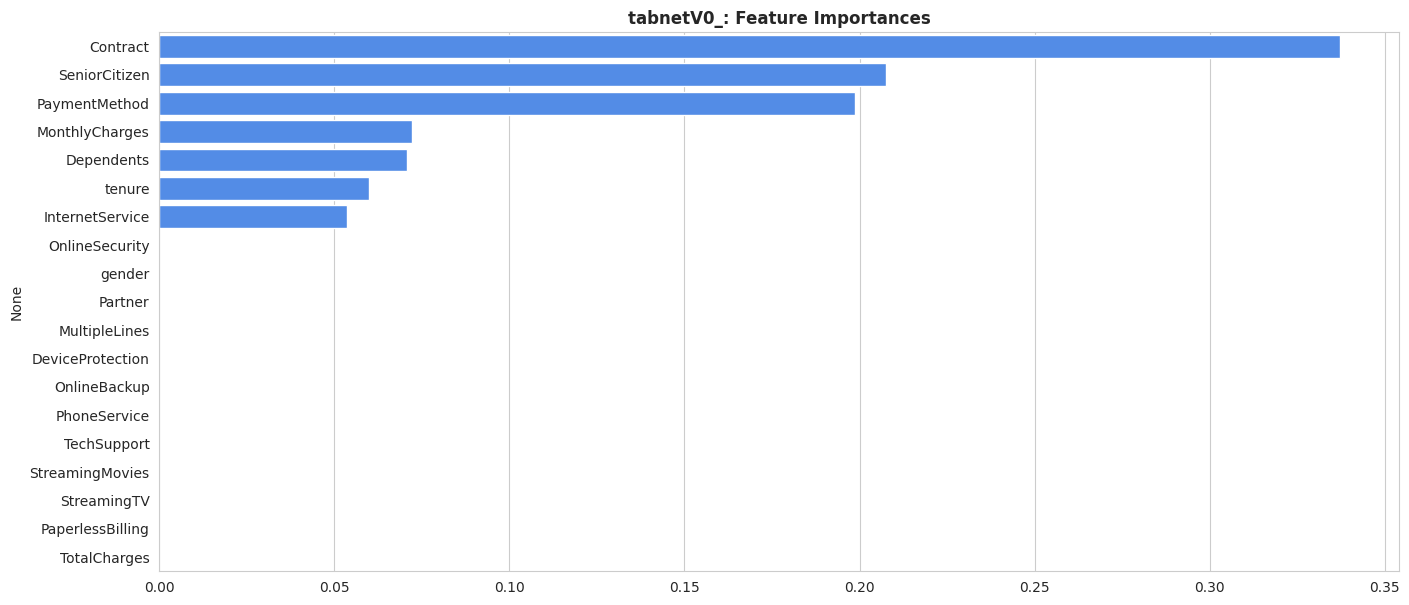

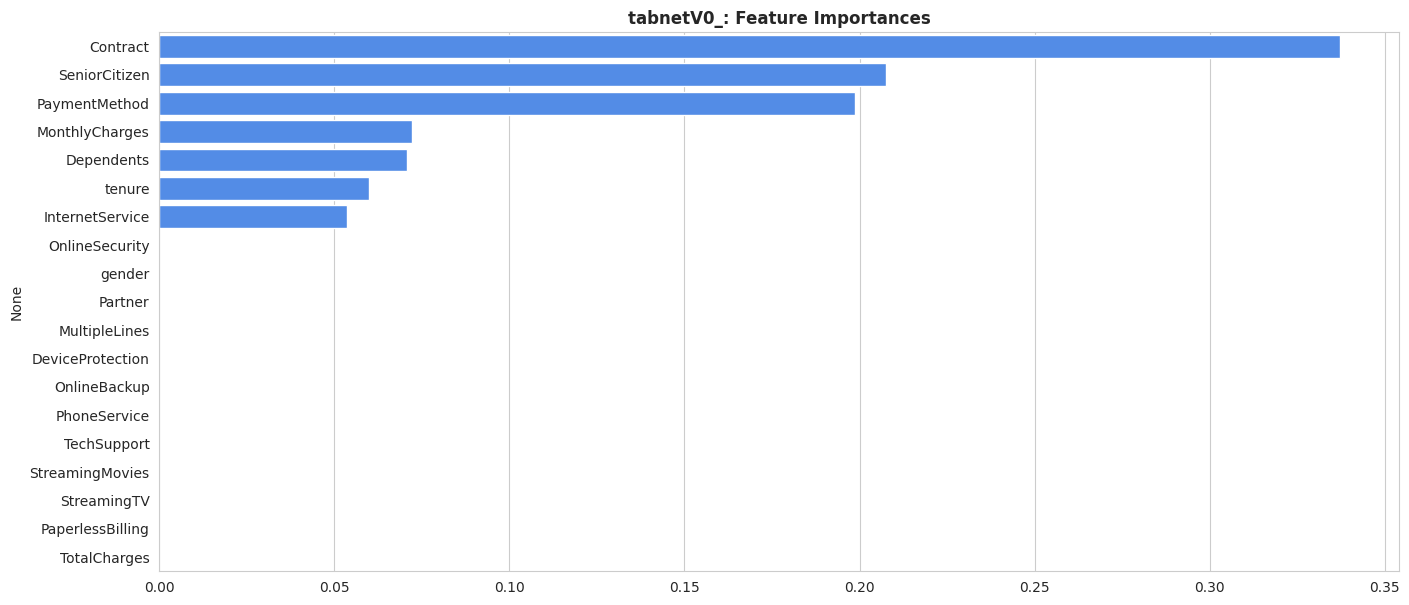

In [22]:
all_models = []

for i, _ in enumerate(list(all_model_predictions.keys())):
    model = all_model_predictions[list(all_model_predictions.keys())[i]]
    all_models.append(model)

## -- TabNet: FEATURE IMPORTANCES --
for m in all_models:
    feat_imp = m['model'].feature_importances_
    features = m['columns']
    df_temp  = pd.Series(dict(zip(features, feat_imp))).sort_values(ascending=False)[:20]

    plt.figure(figsize=(16, 7))
    sns.barplot(y=df_temp.index, x=df_temp.values)
    plt.title(f"{version_name}: Feature Importances", fontweight='semibold')

    # plt.tight_layout()
    plt.show()
    print()

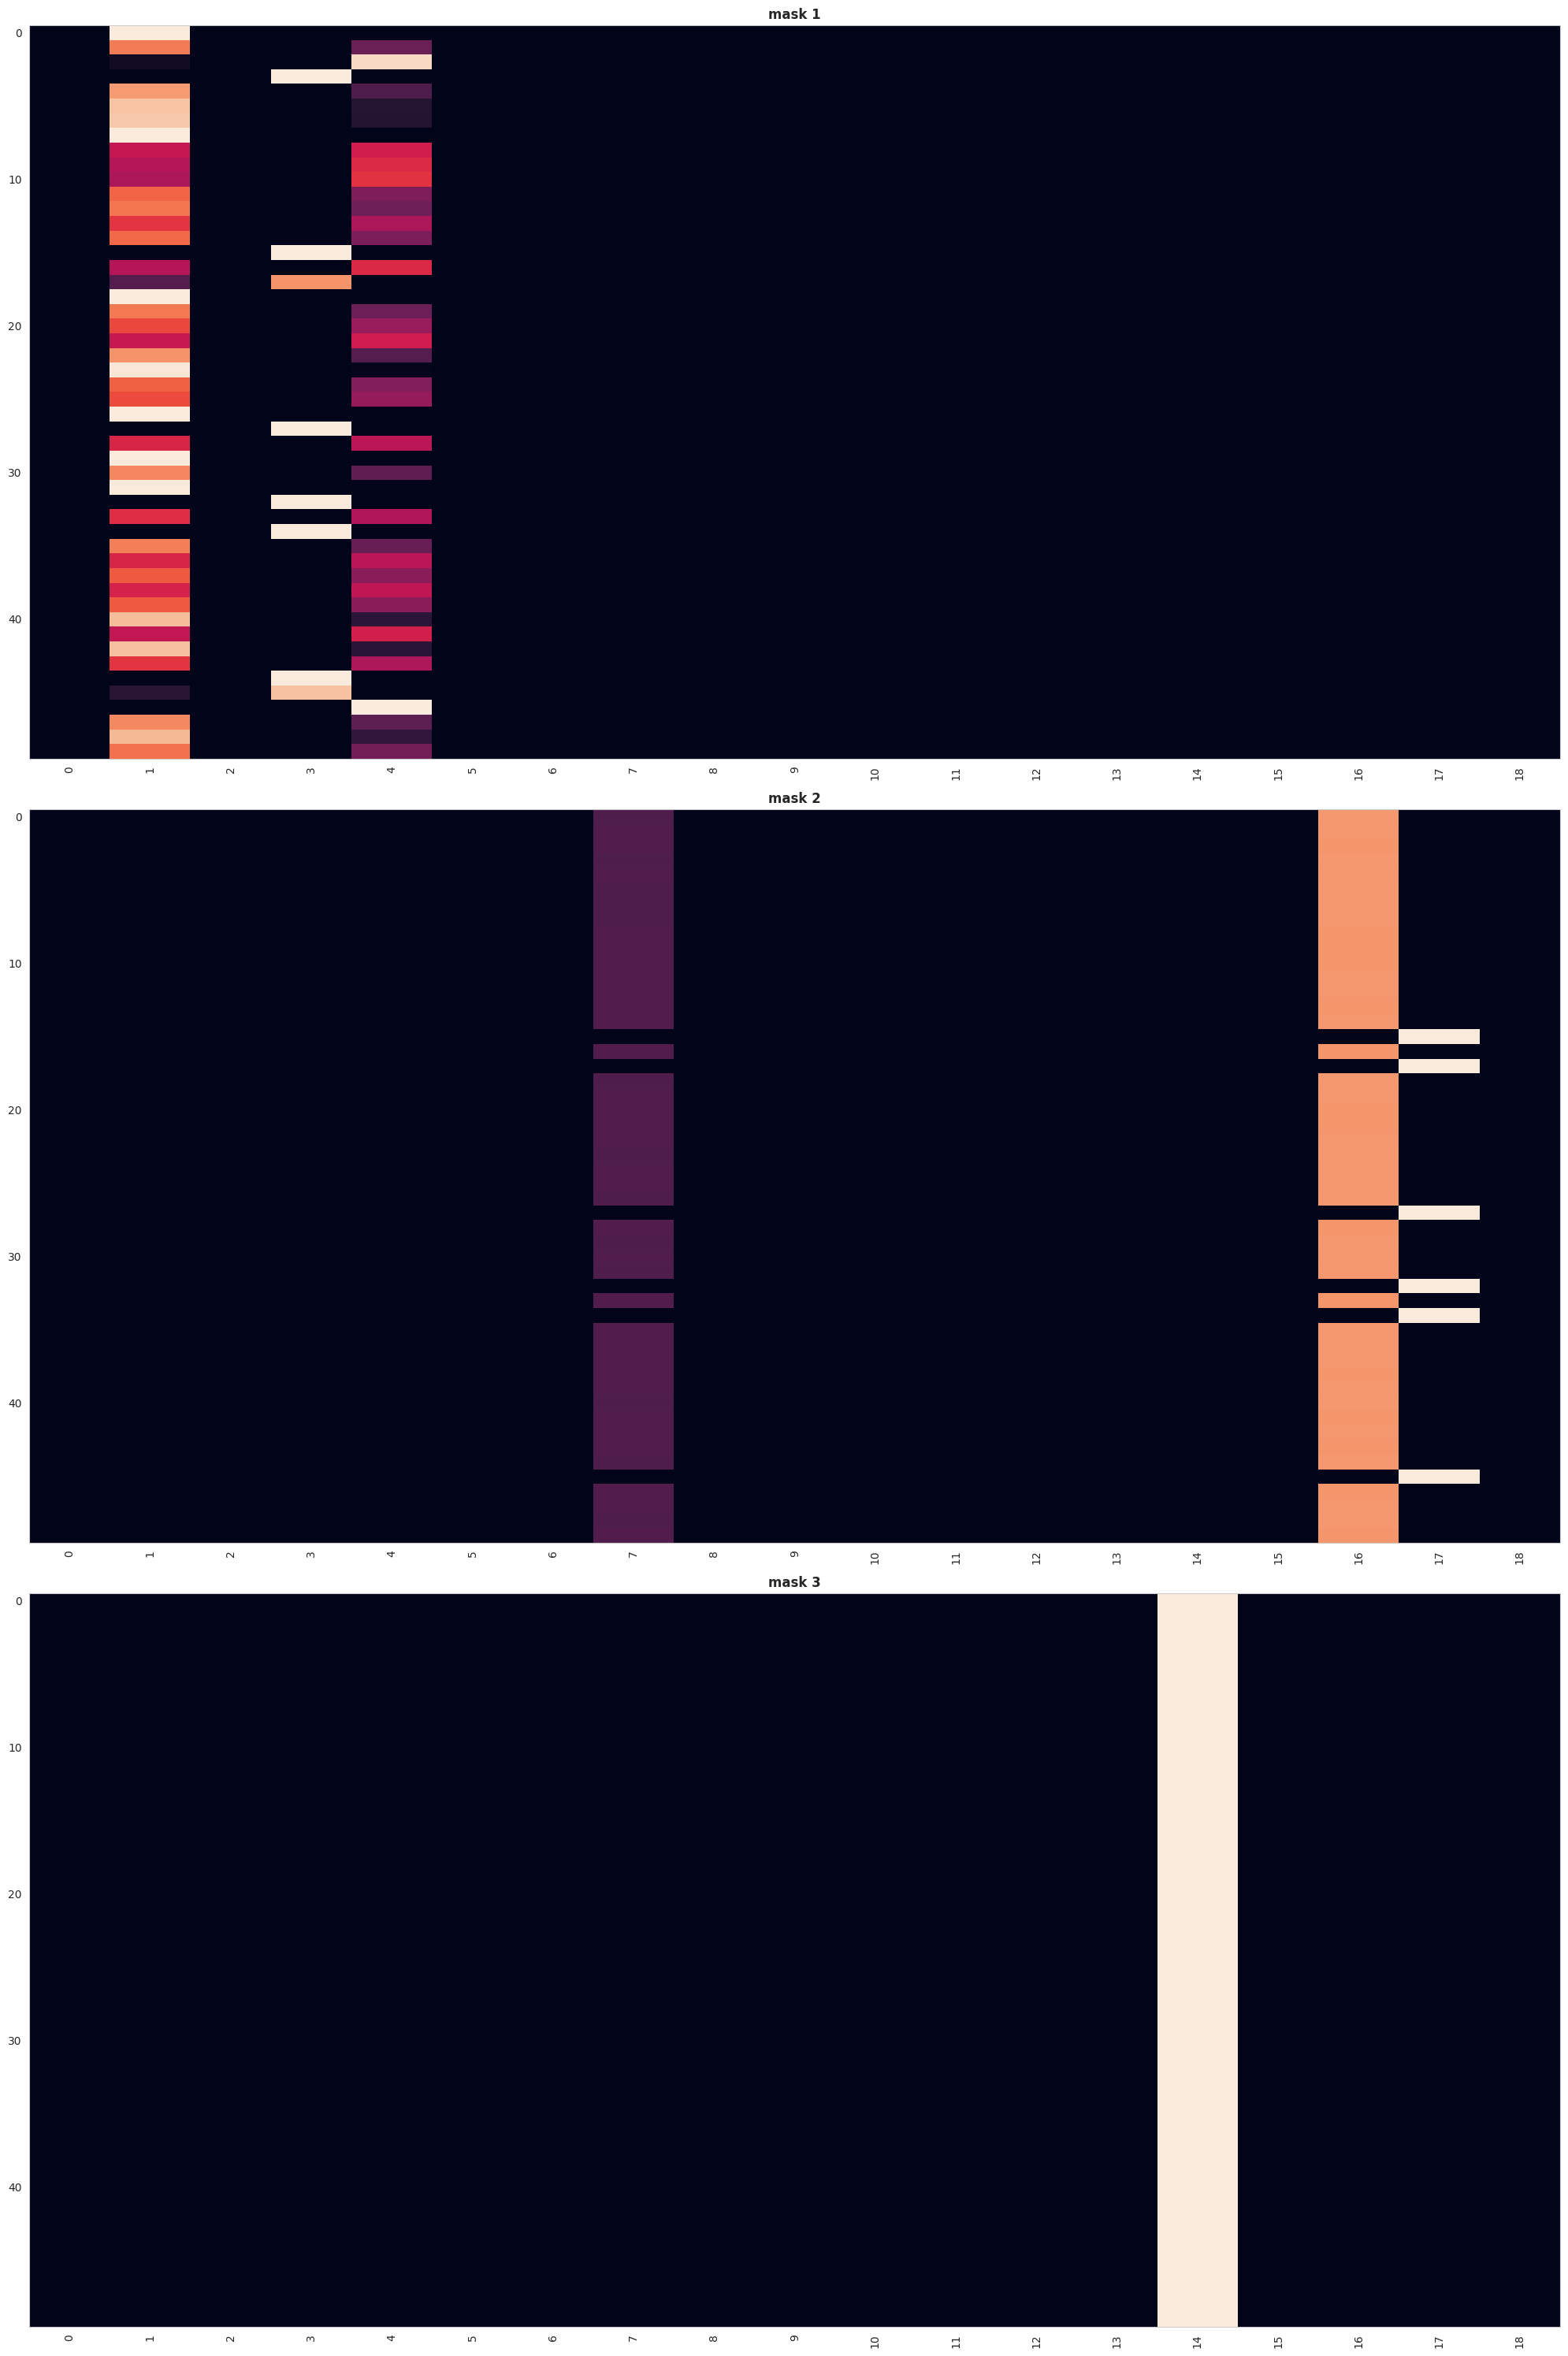

In [23]:
## -- MOST USED FEATURES --
explain_matrix, masks = all_models[0]['model'].explain(all_models[0]['val_data'].to_numpy())

plt.figure(figsize=(20, 30))
for i in range(3):
    ax = plt.subplot(3, 1, i+1)
    ax.imshow(masks[i][:50], aspect='auto')
    ax.set_title(f"mask {i+1}", weight='semibold')
    ax.set_xticks(range(len(all_models[0]['val_data'].columns)))
    ax.tick_params('x', rotation=90)
    ax.grid()
    
plt.tight_layout()
plt.show()